# Segmentación de rutas logísticas

Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("rutas_kmeans.csv")
df.head()


,distancia_km,duracion_horas,coste,num_paradas,carga_kg
0,172.518015,9.087255,279.860763,9,940.289759
1,421.029064,9.323512,764.515440,14,6275.619267
2,271.740794,2.843272,340.179881,3,3061.029973
3,282.570431,4.461356,242.823147,7,2170.728243
4,387.515877,6.050330,552.455544,13,5905.496835


EDA

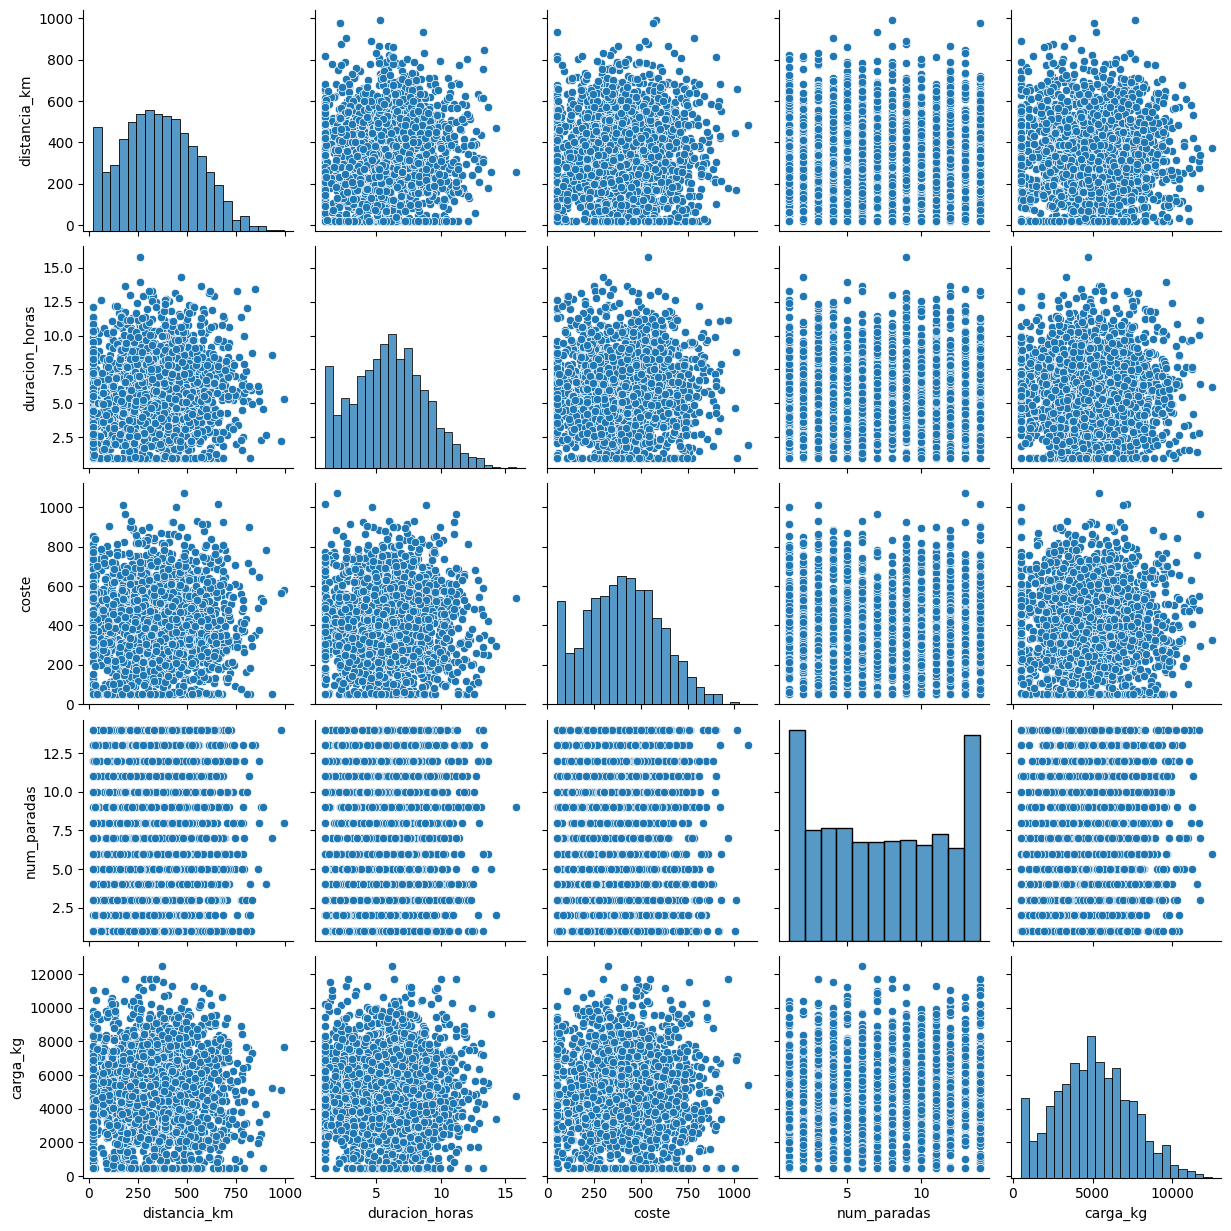

In [3]:
df.describe()
sns.pairplot(df)


Escalar

In [4]:
from sklearn.preprocessing import StandardScaler

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Método del codo

In [ ]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo — Rutas")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.show()


KMeans

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)


Interpretación

In [ ]:
df.groupby("cluster").mean()


,distancia_km,duracion_horas,coste,num_paradas,carga_kg
cluster,,,,,
0,476.563797,7.399728,412.216033,4.203297,4959.043787
1,218.814093,3.962800,374.783353,5.410714,4790.851238
2,371.023806,6.532442,430.786026,11.453890,5299.883901


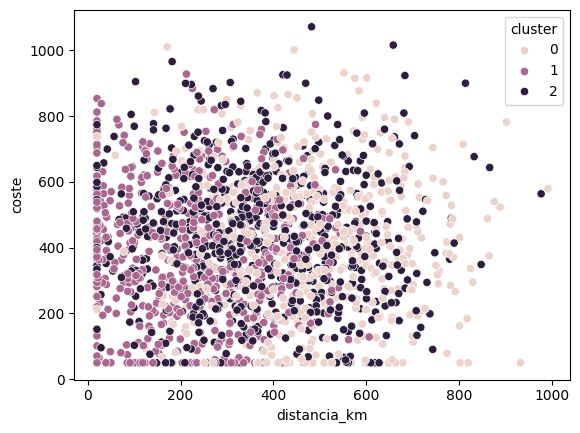

In [ ]:
sns.scatterplot(data=df, x="distancia_km", y="coste", hue="cluster")
plt.show()

